In [1]:
%pip install ucimlrepo


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [47]:
# Import Libraries
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any, Dict

"""
Load the Cardiotocography dataset from UCI repository.
Reference:
    https://archive.ics.uci.edu/dataset/193/cardiotocography
"""

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

CTG_TARGET_COLS = ["NSP", "CLASS"]
NSP_LABELS = {1: "Normal", 2: "Suspect", 3: "Pathologic"}

# 1.Data Loading
def load_cardiotocography_dataset() -> pd.DataFrame:

    ctg = fetch_ucirepo(id=193)

    if ctg.data is None:
        raise ValueError("Failed to fetch dataset from UCI repository.")

    # Combine features and targets
    df = pd.concat([ctg.data.features, ctg.data.targets], axis=1)

    return df

# 1.1 Exploring dataset 
def explore_dataset(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Returns:
        dict: Summary statistics including column types, shape, etc.
    """
    # Identify column types
    cat_cols = [col for col in df.columns if df[col].dtype == 'object']
    num_cols = [col for col in df.columns if df[col].dtype != 'object']

    summary = {
        'shape': df.shape,
        'categorical_columns': cat_cols,
        'numerical_columns': num_cols,
        'total_samples': df.shape[0],
        'total_features': df.shape[1]
    }

    # Display overview
    print("1. DATASET OVERVIEW")
    display(df.head(10))
    print(f"\nColumn Data Types:")
    print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
    print(f"Numerical columns ({len(num_cols)}): {num_cols}")
    print(f"\nDataset Summary:")
    print(f"Total samples: {summary['total_samples']:,}")
    print(f"Total features: {summary['total_features']}")

    return summary
# Load and explore data
df = load_cardiotocography_dataset()
dataset_summary = explore_dataset(df)


1. DATASET OVERVIEW


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,CLASS,NSP
0,120,0.000,0.0,0.000,0.000,0.0,0.000,73,0.5,43,2.4,64,62,126,2,0,120,137,121,73,1,9,2
1,132,0.006,0.0,0.006,0.003,0.0,0.000,17,2.1,0,10.4,130,68,198,6,1,141,136,140,12,0,6,1
2,133,0.003,0.0,0.008,0.003,0.0,0.000,16,2.1,0,13.4,130,68,198,5,1,141,135,138,13,0,6,1
3,134,0.003,0.0,0.008,0.003,0.0,0.000,16,2.4,0,23.0,117,53,170,11,0,137,134,137,13,1,6,1
4,132,0.007,0.0,0.008,0.000,0.0,0.000,16,2.4,0,19.9,117,53,170,9,0,137,136,138,11,1,2,1
5,134,0.001,0.0,0.010,0.009,0.0,0.002,26,5.9,0,0.0,150,50,200,5,3,76,107,107,170,0,8,3
6,134,0.001,0.0,0.013,0.008,0.0,0.003,29,6.3,0,0.0,150,50,200,6,3,71,107,106,215,0,8,3
7,122,0.000,0.0,0.000,0.000,0.0,0.000,83,0.5,6,15.6,68,62,130,0,0,122,122,123,3,1,9,3
8,122,0.000,0.0,0.002,0.000,0.0,0.000,84,0.5,5,13.6,68,62,130,0,0,122,122,123,3,1,9,3
9,122,0.000,0.0,0.003,0.000,0.0,0.000,86,0.3,6,10.6,68,62,130,1,0,122,122,123,1,1,9,3



Column Data Types:
Categorical columns (0): []
Numerical columns (23): ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'CLASS', 'NSP']

Dataset Summary:
Total samples: 2,126
Total features: 23


In [3]:
#get a concise summary of the dataset including data types, non-null counts, and memory usage.
df.info()
#.describe method enable us to detect outliers in the data for further investigation
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   int64  
 1   AC        2126 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2126 non-null   float64
 6   DP        2126 non-null   float64
 7   ASTV      2126 non-null   int64  
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   int64  
 10  MLTV      2126 non-null   float64
 11  Width     2126 non-null   int64  
 12  Min       2126 non-null   int64  
 13  Max       2126 non-null   int64  
 14  Nmax      2126 non-null   int64  
 15  Nzeros    2126 non-null   int64  
 16  Mode      2126 non-null   int64  
 17  Mean      2126 non-null   int64  
 18  Median    2126 non-null   int64  
 19  Variance  2126 non-null   int64  
 20  Tendency  2126 non-null   int6

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,CLASS,NSP
count,2126.00,2126.00,2126.00,2126.00,2126.00,2126.0,2126.0,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00
mean,133.30,0.00,0.01,0.00,0.00,0.0,0.0,46.99,1.33,9.85,8.19,70.45,93.58,164.03,4.07,0.32,137.45,134.61,138.09,18.81,0.32,4.51,1.30
std,9.84,0.00,0.05,0.00,0.00,0.0,0.0,17.19,0.88,18.40,5.63,38.96,29.56,17.94,2.95,0.71,16.38,15.59,14.47,28.98,0.61,3.03,0.61
min,106.00,0.00,0.00,0.00,0.00,0.0,0.0,12.00,0.20,0.00,0.00,3.00,50.00,122.00,0.00,0.00,60.00,73.00,77.00,0.00,-1.00,1.00,1.00
25%,126.00,0.00,0.00,0.00,0.00,0.0,0.0,32.00,0.70,0.00,4.60,37.00,67.00,152.00,2.00,0.00,129.00,125.00,129.00,2.00,0.00,2.00,1.00
50%,133.00,0.00,0.00,0.00,0.00,0.0,0.0,49.00,1.20,0.00,7.40,67.50,93.00,162.00,3.00,0.00,139.00,136.00,139.00,7.00,0.00,4.00,1.00
75%,140.00,0.01,0.00,0.01,0.00,0.0,0.0,61.00,1.70,11.00,10.80,100.00,120.00,174.00,6.00,0.00,148.00,145.00,148.00,24.00,1.00,7.00,1.00
max,160.00,0.02,0.48,0.02,0.02,0.0,0.0,87.00,7.00,91.00,50.70,180.00,159.00,238.00,18.00,10.00,187.00,182.00,186.00,269.00,1.00,10.00,3.00


In [44]:
# 2. Cleaning missing values on dataset
"""
Clean missing values in the dataset by replacing specified placeholders with NaN.
If found any missing values then drop those rows.
Args:
    df: Input DataFrame
    missing_value: Placeholder for missing values (default is '?')
Returns:
    pd.DataFrame: Cleaned DataFrame with missing values handled
Reference:
    https://www.geeksforgeeks.org/data-analysis/data-cleansing-introduction/
"""

def analyze_missing_values(df: pd.DataFrame, missing_value: str = '?') -> pd.DataFrame:

    print("2. MISSING VALUE ANALYSIS")

    missing_info = []

    # 2.1 Check object columns for placeholder missing values
    object_cols = df.select_dtypes(include=['object']).columns

    for col in object_cols:
        missing_count = (df[col] == missing_value).sum()
        if missing_count > 0:
            missing_pct = (missing_count / len(df)) * 100
            missing_info.append({
                'column': col,
                'missing_count': missing_count,
                'missing_percentage': round(missing_pct, 2)
            })

    # 2.2 Check all columns for NaN values
    nan_counts = df.isnull().sum()
    if nan_counts.sum() > 0:
        print("\nNaN values found:")
        print(nan_counts[nan_counts > 0])
    else:
        print("\nNo NaN values found.")

# 2.3 Check numeric columns for placeholder values (-1, 0 used as missing)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [c for c in numeric_cols if c not in CTG_TARGET_COLS]

    zero_counts = (df[numeric_cols] == 0).sum()
    zero_counts = zero_counts[zero_counts > 0]
    if not zero_counts.empty:
        print(f"\nColumns with zeros (potential missing indicators):")
        print(zero_counts.to_string())

    if not missing_info:
        print("\nNo '?' placeholder missing values found.")

    return pd.DataFrame(missing_info) if missing_info else pd.DataFrame(
        columns=['column', 'missing_count', 'missing_percentage']
    )


# Analyze missing values '?' and NaN
missing_summary = analyze_missing_values(df)
display(missing_summary)




2. MISSING VALUE ANALYSIS

No NaN values found.

Columns with zeros (potential missing indicators):
AC           894
FM          1311
UC           332
DL          1231
DS          2119
DP          1948
ALTV        1240
MLTV         137
Nmax         107
Nzeros      1624
Variance     187
Tendency    1115

No '?' placeholder missing values found.


,column,missing_count,missing_percentage


3. TARGET DISTRIBUTION


/var/folders/_x/91hn0bv175n56mgwdc2zs2n40000gp/T/ipykernel_51503/3694900070.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=plot_series, order=order, palette='Set2', ax=axes[0])


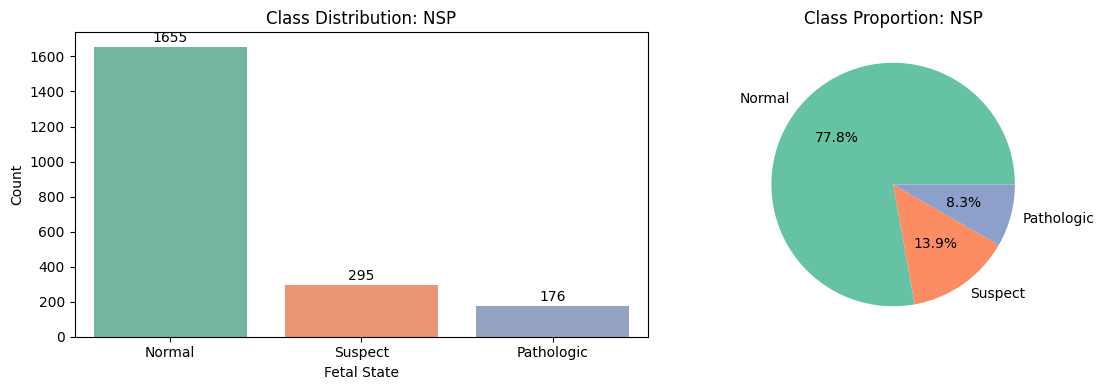

Findings — Target Distribution

  - Normal: ~78% (1,655 cases)
  - Suspect: ~14% (295 cases)
  - Pathologic: ~8% (176 cases)


In [40]:
# 3. Exploratory Data Analysis (EDA)
"""
Explore the distribution of the target variable and features.
Args:
    df: Input DataFrame
Returns:
    None
Reference:
    https://www.geeksforgeeks.org/exploratory-data-analysis-in-python/
"""

# 3.1 Target distribution
def plot_target_distribution(df: pd.DataFrame, target_col: str = 'NSP') -> None:

    print("3. TARGET DISTRIBUTION")

    # Map numeric labels to readable names
    plot_series = df[target_col].map(NSP_LABELS)
    order = ['Normal', 'Suspect', 'Pathologic']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Count plot
    sns.countplot(x=plot_series, order=order, palette='Set2', ax=axes[0])
    axes[0].set_title(f'Class Distribution: {target_col}')
    axes[0].set_xlabel('Fetal State')
    axes[0].set_ylabel('Count')
    for bar in axes[0].patches:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f'{int(bar.get_height())}',
            ha='center', va='bottom', fontsize=10
        )

    # Pie chart
    counts = plot_series.value_counts().reindex(order)
    axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
                colors=sns.color_palette('Set2', len(counts)))
    axes[1].set_title(f'Class Proportion: {target_col}')

    plt.tight_layout()
    plt.show()

    # 3.1 Findings
    print('Findings — Target Distribution\n')
  
    for label in order:
        count = (plot_series == label).sum()
        pct = (count / len(plot_series)) * 100
        print(f'  - {label}: ~{pct:.0f}% ({count:,} cases)')
  
# Plot target distribution
plot_target_distribution(df, 'NSP')

The dataset is **imbalanced**:
**Modeling consideration:** Accuracy alone is misleading here. We will use **macro F1-score** and **stratified splits** to ensure minority classes are represented. Classifiers will use `class_weight='balanced'`.

 FEATURE DISTRIBUTIONS — Overview


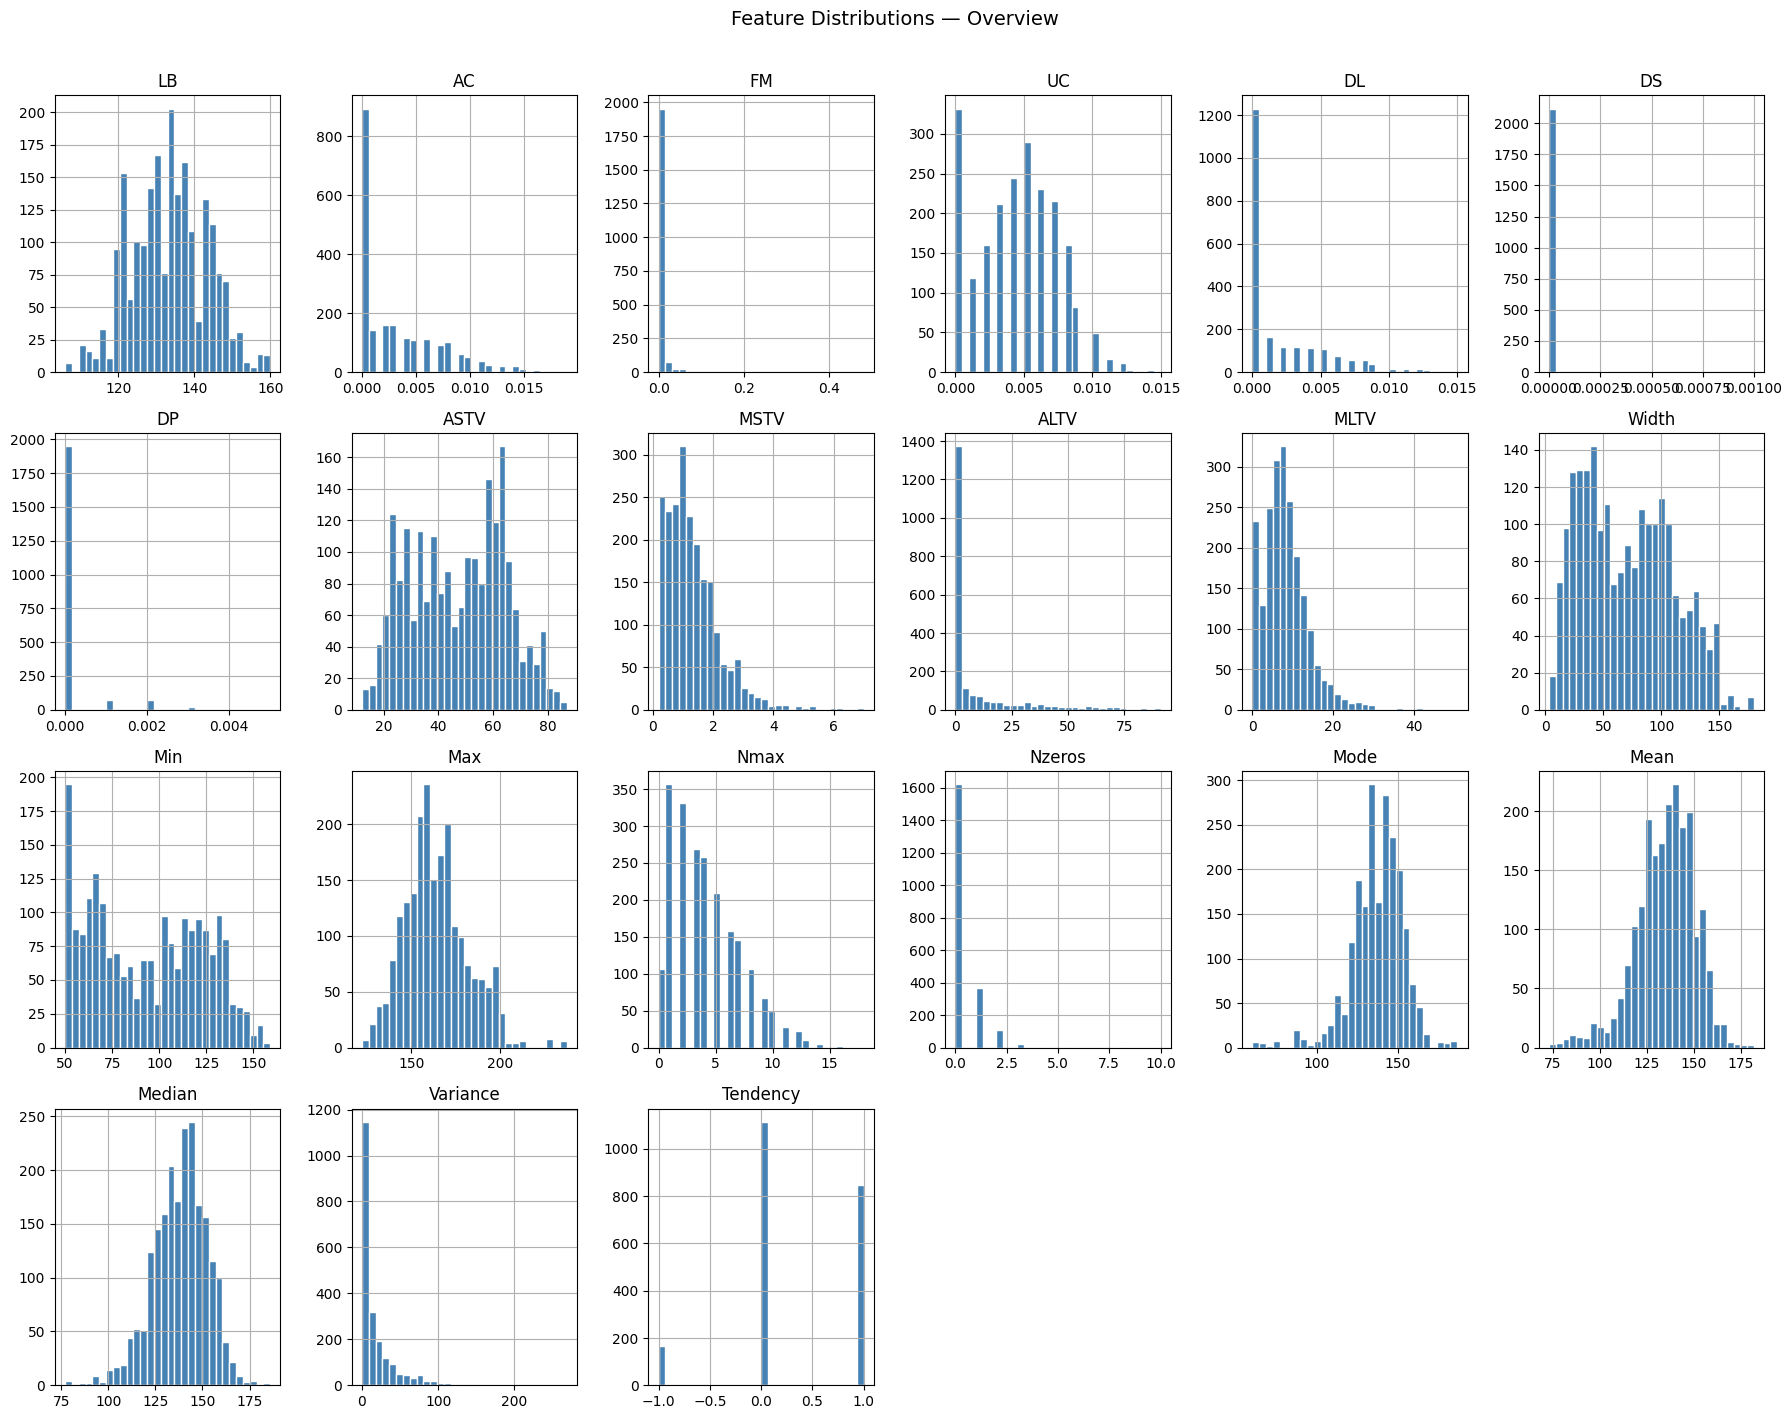

 FEATURE DISTRIBUTIONS — Statistical Markers


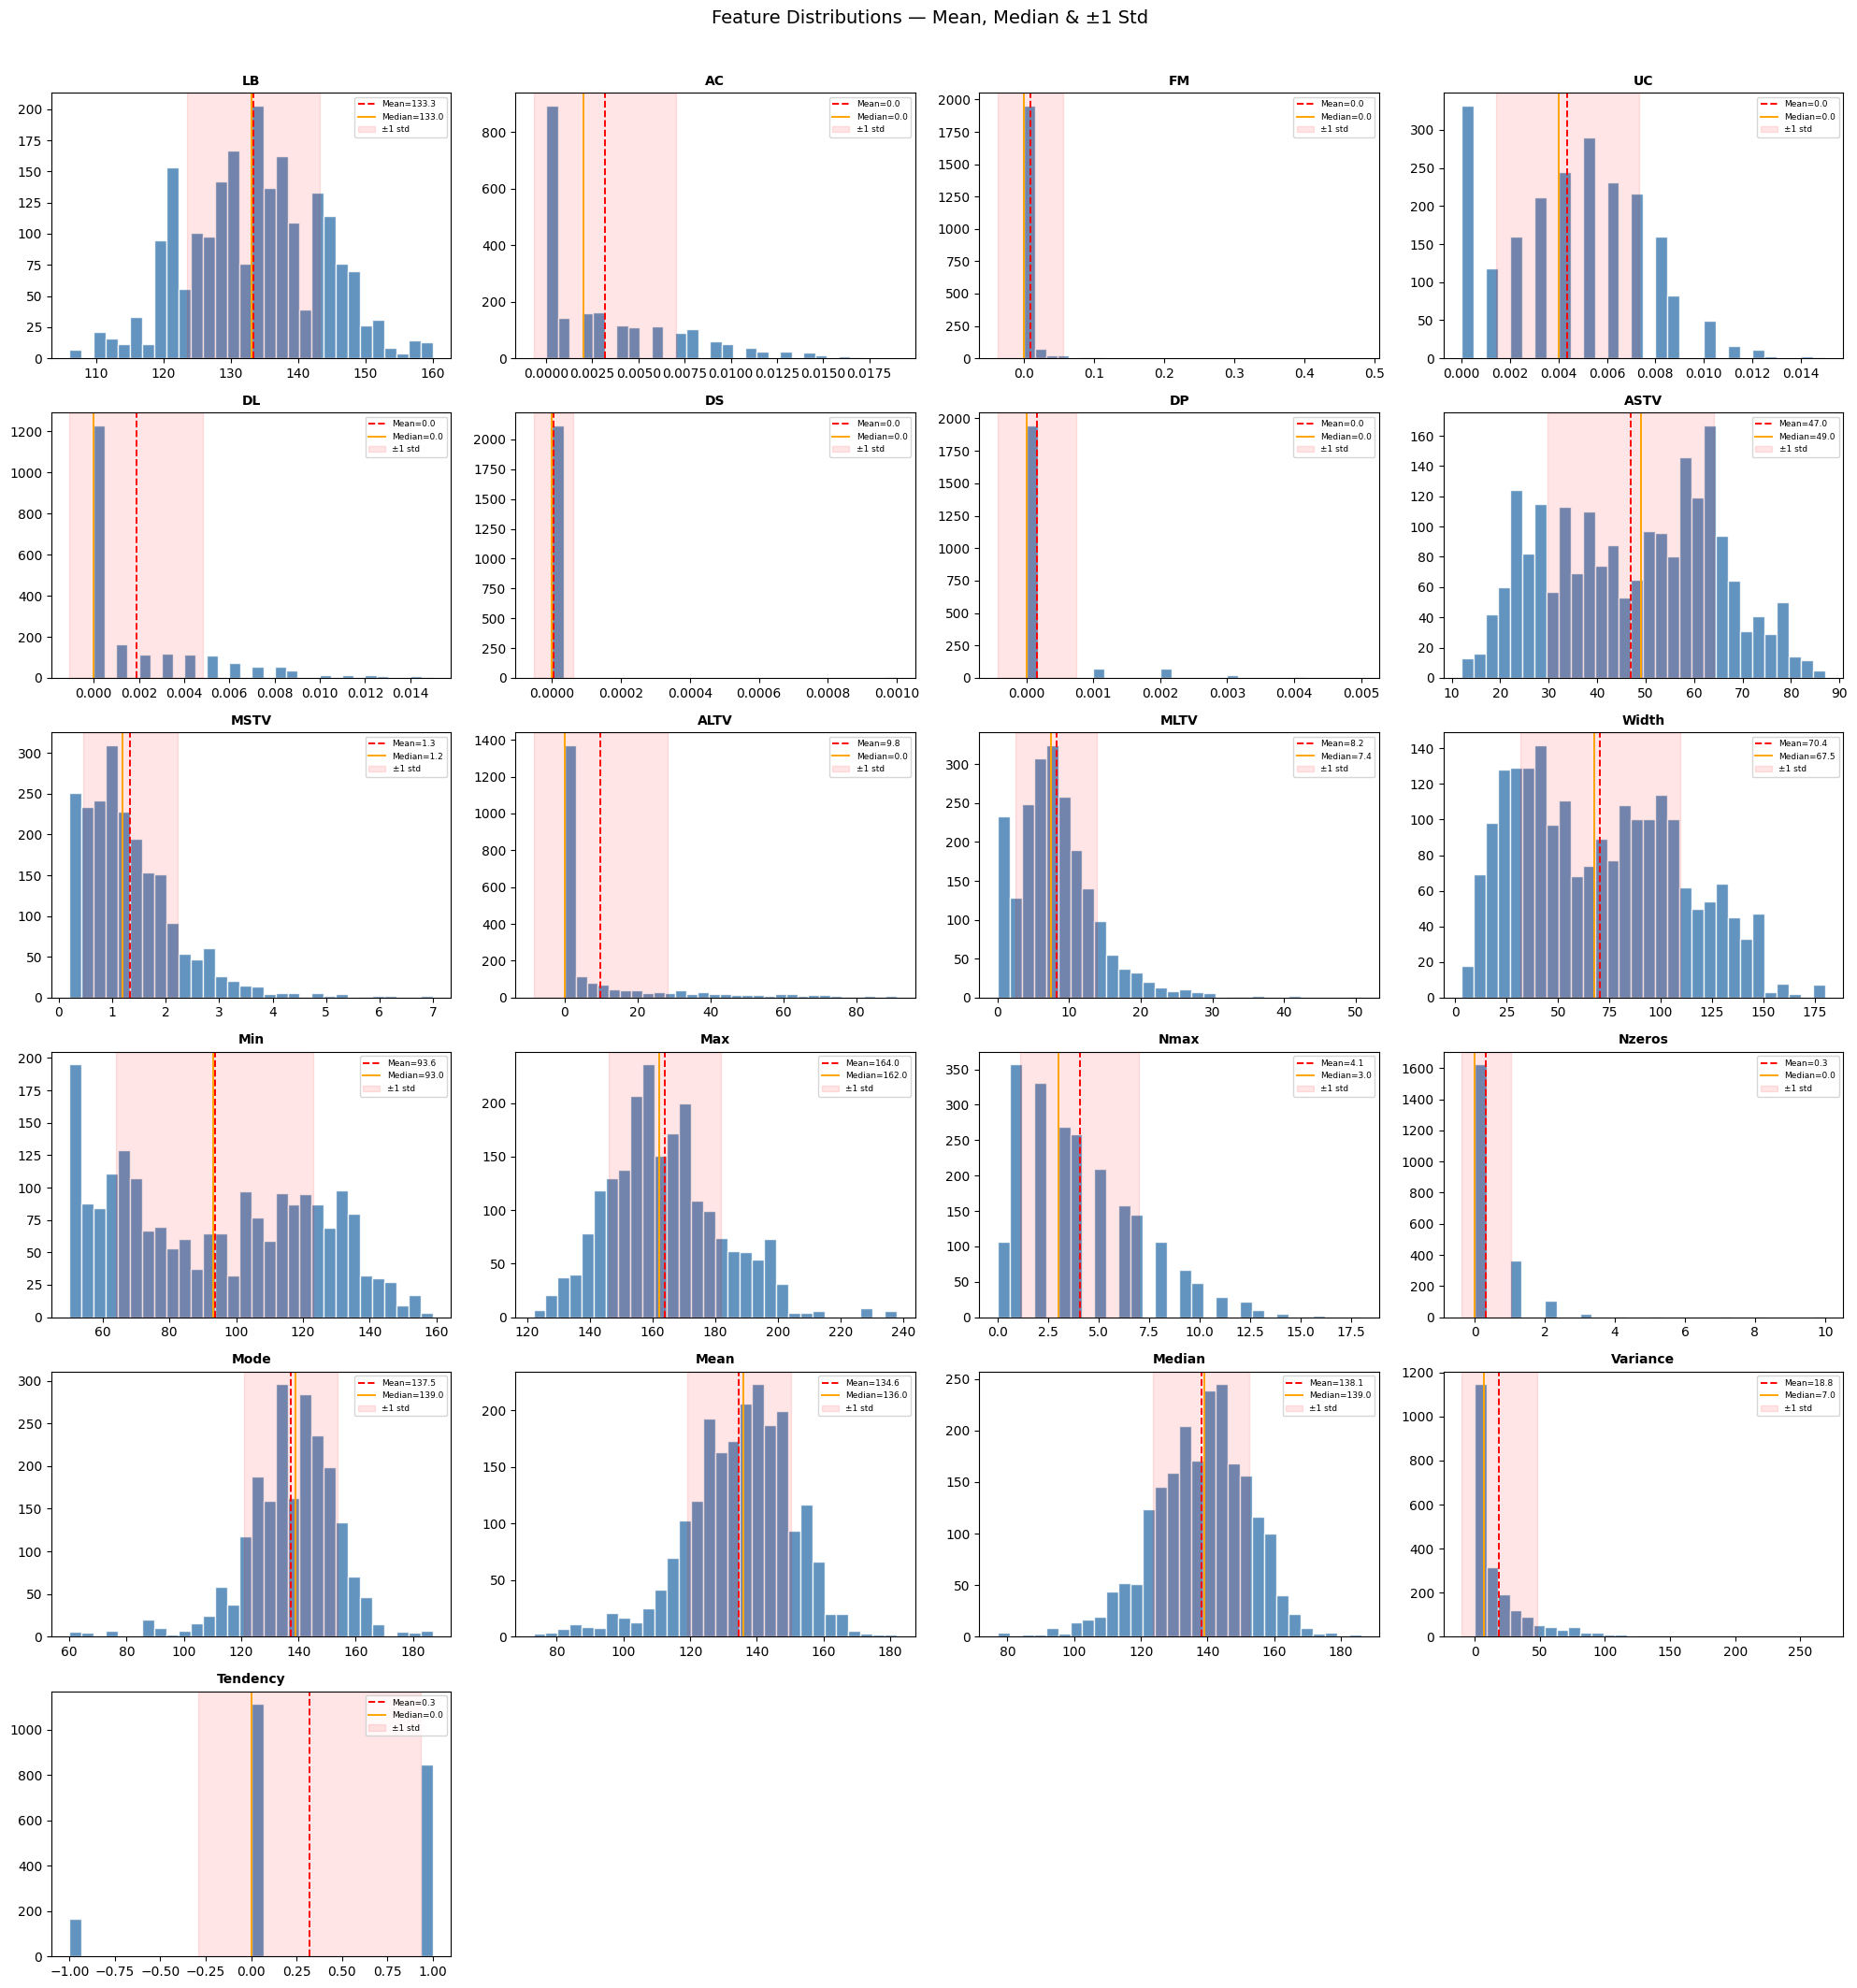


Highly skewed features (|skew| > 1):
DS          17.34
FM           7.81
DP           4.32
Nzeros       3.92
Variance     3.22
ALTV         2.19
DL           1.72
MSTV         1.66
MLTV         1.33
AC           1.20


In [50]:
# 3.2 Feature distributions
from scipy.stats import skew
"""
Plot histograms for all numerical features to understand
their distributions and spot potential outliers.
"""

# 3.2.1 Basic feature distributions
def plot_feature_distributions(df: pd.DataFrame) -> None:
    """
    Plot basic histograms for a quick overview of all feature distributions.
    """
    print(" FEATURE DISTRIBUTIONS — Overview")

    feature_cols = [c for c in df.columns if c not in CTG_TARGET_COLS]

    df[feature_cols].hist(
        bins=30,
        figsize=(18, 14),
        color='steelblue',
        edgecolor='white',
        layout=(4, 6)
    )
    plt.suptitle('Feature Distributions — Overview', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


# 3.2.2 Enhanced feature distributions with statistical markers
def plot_feature_distributions_stats(df: pd.DataFrame) -> None:
    """
    Plot histograms with mean, median, and ±1 std markers
    to identify skewness and outliers per feature.
    """
    print(" FEATURE DISTRIBUTIONS — Statistical Markers")

    feature_cols = [c for c in df.columns if c not in CTG_TARGET_COLS]

    n_cols = 4
    n_rows = -(-len(feature_cols) // n_cols)  # ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        ax = axes[i]
        data = df[col].dropna()

        col_mean   = data.mean()
        col_median = data.median()
        col_std    = data.std()

        # Histogram
        ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)

        # Mean line
        ax.axvline(col_mean,   color='red',    linestyle='--', linewidth=1.4,
                   label=f'Mean={col_mean:.1f}')
        # Median line
        ax.axvline(col_median, color='orange', linestyle='-',  linewidth=1.4,
                   label=f'Median={col_median:.1f}')
        # ±1 std shaded band
        ax.axvspan(col_mean - col_std, col_mean + col_std,
                   alpha=0.10, color='red', label='±1 std')

        ax.set_title(col, fontsize=10, fontweight='bold')
        ax.set_xlabel('')
        ax.legend(fontsize=6.5, loc='upper right')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Feature Distributions — Mean, Median & ±1 Std',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # Flag skewed features
    skewness = df[feature_cols].apply(skew).sort_values(ascending=False)
    highly_skewed = skewness[abs(skewness) > 1]

    print('\nHighly skewed features (|skew| > 1):')
    print(highly_skewed.round(2).to_string())


# Run both
plot_feature_distributions(df)
plot_feature_distributions_stats(df)

### 3.2 Findings — Feature Distributions

| Feature(s) | Shape | What it means |
|-----------|-------|---------------|
| `LB`, `Mean`, `Median`, `Mode`, `Min`, `Max` | Normal / Symmetric | Stable bell-shaped distributions — strong predictive candidates |
| `AC`, `FM`, `UC`, `DL`, `DS`, `DP`, `Variance`, `Width` | Right-Skewed | Mass near zero with long tails — zeros reflect normal clinical absence of those events |
| `ASTV`, `MSTV`, `ALTV`, `MLTV` | Multi-Modal | Wide spreads or multi-peak patterns — likely represent distinct physiological states across patients |
| `Nmax`, `Nzeros` | Discrete / Sparse | Integer event counts with low variance — potentially weak standalone predictors |
| `Tendency` | Discrete / Sparse | Clusters at `-1`, `0`, `+1` — acts as a direction indicator |
| `DL`, `DS`, `DP`, `Variance`, `Width` | Extreme Outliers | Sparse extreme values — may require clipping or robust scaling for linear models |

3.4 FEATURE DISTRIBUTIONS BY CLASS


/var/folders/_x/91hn0bv175n56mgwdc2zs2n40000gp/T/ipykernel_51503/1093094088.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/_x/91hn0bv175n56mgwdc2zs2n40000gp/T/ipykernel_51503/1093094088.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/_x/91hn0bv175n56mgwdc2zs2n40000gp/T/ipykernel_51503/1093094088.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/_x/91hn0bv175n56mgwdc2zs2n40000gp/T/ipykernel_51503/1093094088.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

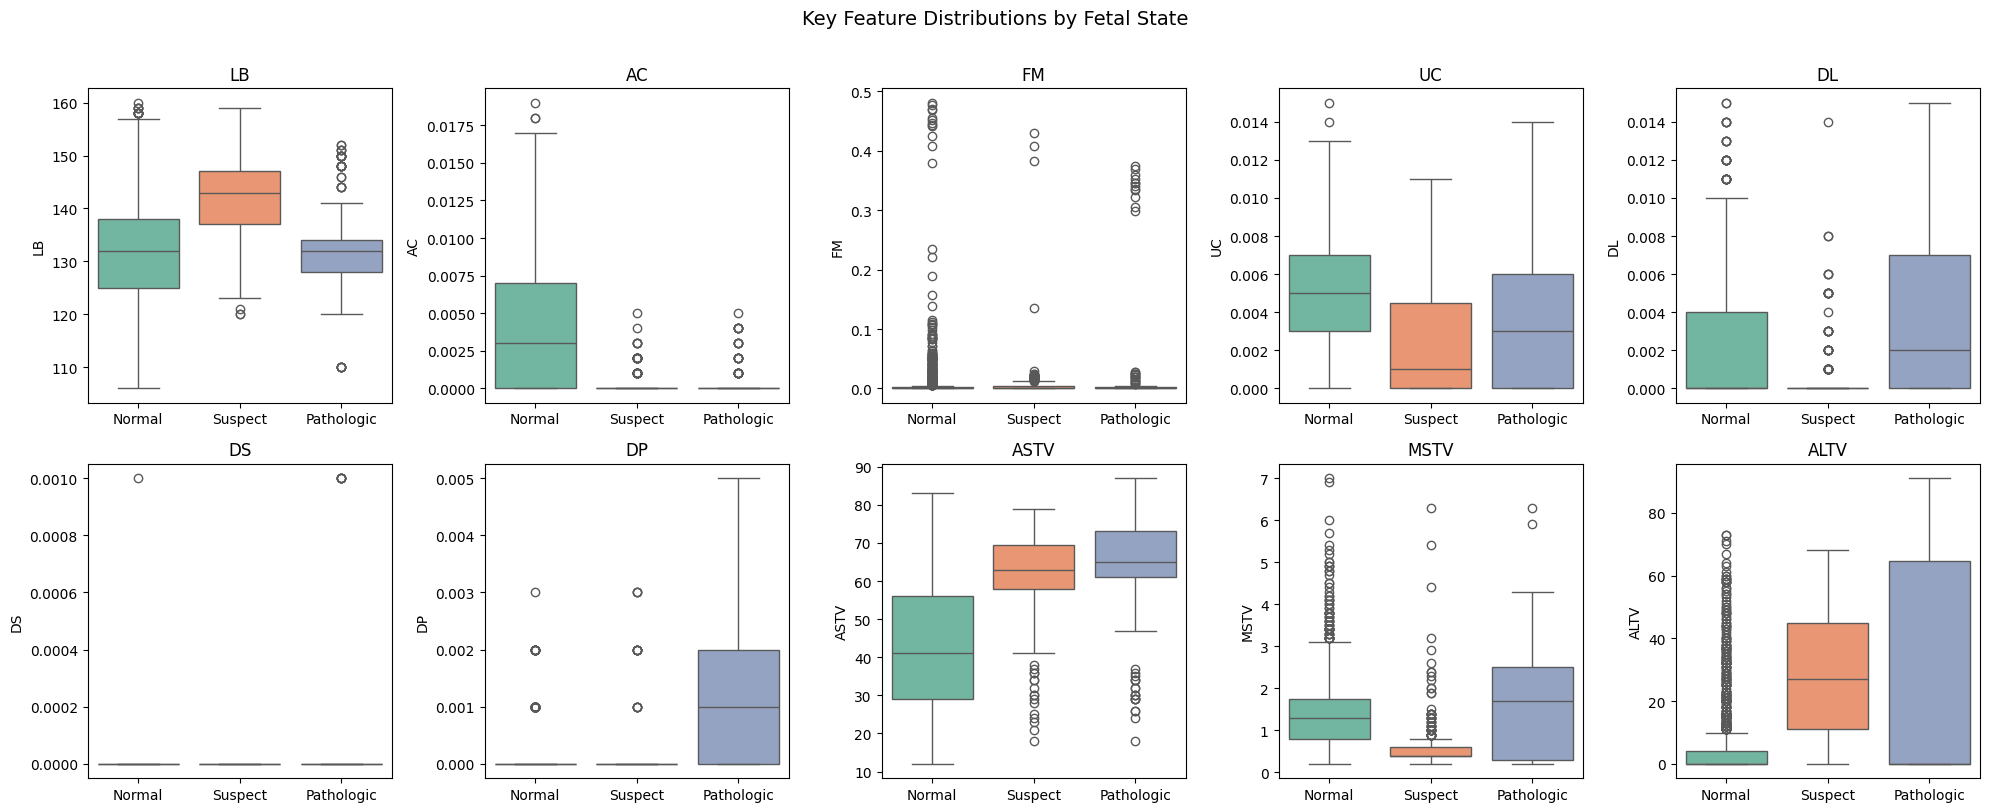

In [51]:
# 3.3 Feature distributions by class
"""
Plot boxplots for key clinical features grouped by NSP class
to visualize how features differ across fetal states.
"""

def plot_features_by_class(df: pd.DataFrame, target_col: str = 'NSP') -> None:

    print("3.4 FEATURE DISTRIBUTIONS BY CLASS")

    # Key clinical features to compare
    key_features = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV']

    plot_df = df.copy()
    plot_df[target_col] = plot_df[target_col].map(NSP_LABELS)
    order = ['Normal', 'Suspect', 'Pathologic']

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for i, feature in enumerate(key_features):
        sns.boxplot(
            data=plot_df,
            x=target_col,
            y=feature,
            order=order,
            palette='Set2',
            ax=axes[i]
        )
        axes[i].set_title(feature)
        axes[i].set_xlabel('')

    plt.suptitle('Key Feature Distributions by Fetal State', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# Plot features by class
plot_features_by_class(df, 'NSP')

### 3.3 Findings — Feature Distributions by Class

#### Feature Separability Summary

| Feature | Normal | Suspect | Pathologic | Tier | Clinical Meaning |
|---------|--------|---------|------------|------|-----------------|
| `ASTV` | Low | Higher | Very High (~80-90%) | S | Abnormal short-term variability — strongest separator |
| `ALTV` | Small | Moderate | Very high spread | S | Abnormal long-term variability — direct fetal compromise |
| `LB` | ~130-140 bpm | Slightly higher | ~110-120 bpm | S | Depressed baseline FHR = distress indicator |
| `AC` | Highest | Near zero | Near zero | S | Loss of accelerations = hallmark of fetal distress |
| `DL` | Near zero | Slightly higher | Much higher | S | More frequent decelerations = higher risk |
| `DP` | Near zero | Near zero | Wide/High range | S | Prolonged decelerations = severe distress |
| `MSTV` | Smallest | Moderate | Noticeably larger | A | Good directional separation |
| `UC` | Low/tight | Intermediate | High/spread | A | Higher contractions correlate with fetal stress |
| `FM` | Near zero | Near zero | Near zero + outliers | B | Weak separator — similar across all classes |
| `DS` | Near zero | Near zero | Rare outliers | B | Sparse but highly significant when present |

---

#### Overall Fetal State Pattern

| Characteristic | Normal | Suspect | Pathologic |
|----------------|--------|---------|------------|
| Baseline FHR (`LB`) | Stable ~130-140 bpm | Slightly shifted | Depressed ~110-120 bpm |
| Accelerations (`AC`) | High | Low | Near absent |
| Variability (`ASTV`, `ALTV`) | Low/tight | Moderate | Very high/unstable |
| Decelerations (`DL`, `DP`) | Minimal | Occasional | Frequent/severe |
| Contractions (`UC`) | Low | Moderate | High |
| Distribution spread | Tight | Intermediate | Wide/erratic |

---

> **Modeling Considerations:**
> - **Top features:** `ASTV`, `ALTV`, `AC`, `LB`, `DL`, `DP` — use all in initial model
> - `FM`, `DS` are weak predictors but it may contribute in ensemble models
> - Heavy outliers in `DP`, `FM`, `DS` favor **tree-based models** (Random Forest, XGBoost)
> - Suspect class sits predictably between Normal and Pathologic — consistent with clinical CTG guidelines

In [ ]:
##Jasmine Feel free to add here a correlation heatmap formore exploration

## Make sure we have clear functions :)

##Add a markdown cell to summarize the findings. I loooove tables since they are easier to read and understand.


## EDA Summary — Key Findings & Modeling Decisions

---

### 1. The Dataset is Unbalanced
Most recordings in this dataset are from healthy fetuses:
- **Normal: ~78%** (1,655 cases)
- **Suspect: ~14%** (295 cases)
- **Pathologic: ~8%** (176 cases)

This matters because a model could simply predict like "Normal" every time and still be 78% accurate — while completely missing every dangerous case.

**What we should consider @Jasmine & @Lashana REVIEW THIS :**
- Measure model performance using macro F1-score (treats all three classes equally)
- Use stratified splits (keeps the same class proportions in train and test sets)
- Tell the model to pay more attention to rare classes using `class_weight='balanced'`

---

### 2. Features Have Very Different Scales and Shapes
Some features like `LB` (heart rate) range from 100–180, while others like `DS` (severe decelerations) are almost always zero with rare spikes.

**What we will do:**
- For **linear models** (Logistic Regression, SVM): normalize all features to the same scale using `StandardScaler`, and apply log/sqrt transformation to compress the extreme values in `AC`, `FM`, `DS`, `DP`, `Variance`
- For **tree-based models** (Random Forest, XGBoost): no transformation needed because these models handle uneven scales and skewed data naturaly

---

### 3. Some Features Have Extreme Outliers
Features like `DS`, `DP`, `FM`, `Variance`, and `Width` are near zero for most patients but occasionally show very large values. These are not errors but they represent rare but clinically significant events.

**What we will do:**
- Prefer **tree-based models** which are robust to these extreme values

---

### 4. Most Useful Features for Prediction

| Feature | What it measures | Why it matters |
|---------|-----------------|----------------|
| `ASTV` | % of time with abnormal short-term heart rate variability | Much higher in Pathologic cases — strongest signal |
| `AC` | Number of accelerations (heart rate speeding up) | Nearly absent in Pathologic cases |
| `LB` | Baseline fetal heart rate | Lower in Pathologic cases — sign of distress |
| `DP` | Prolonged decelerations (heart rate drops) | More frequent and severe in Pathologic cases |
| `ALTV` | % of time with abnormal long-term variability | Directly linked to fetal compromise |
| `Mean`, `Median` | Average heart rate statistics | Stable and consistent signal across recordings |
| `MLTV`, `Variance` | Variability measures | Capture how erratic the heart rate pattern is |